In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce GTX 1650


In [2]:
# ============================================================
#  Water Quality Classification - Dual-Branch Cross-Attention
#  Temporal Transformer with XAI Integration
#  رسالة الماجستير - نموذج تصنيف جودة المياه
# ============================================================

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, roc_curve, auc
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [3]:
# ─────────────────────────────────────────────
# SECTION 1: Data Loading & EDA
# ─────────────────────────────────────────────
df = pd.read_csv("Combined Data/Combined_dataset.csv")
 

In [4]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           str    
 1   Area                              str    
 2   Waterbody Type                    str    
 3   Date                              str    
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          str    
dtypes: float64(9), str(5)
memory usage: 302.1 MB


In [5]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [6]:
df["CCME_WQI"].value_counts()

CCME_WQI
Good         1033709
Excellent    1020710
Marginal      328734
Fair          317856
Poor          126968
Name: count, dtype: int64

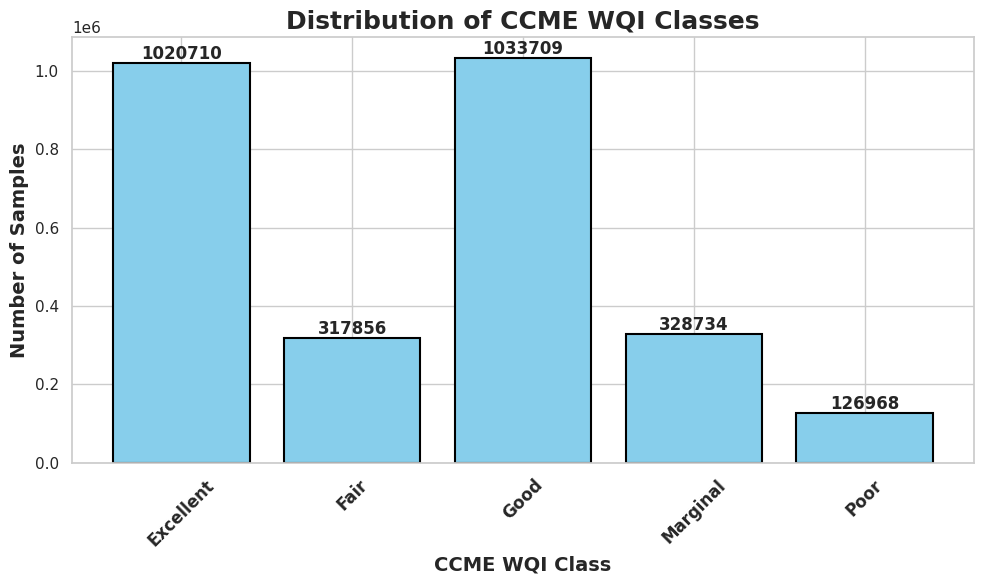

In [7]:
# --- Distribution Bar ---
distribution = df["CCME_WQI"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
bars = plt.bar(distribution.index, distribution.values, color="skyblue",
               edgecolor="black", linewidth=1.5)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{int(h)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title("Distribution of CCME WQI Classes", fontsize=18, fontweight="bold")
plt.xlabel("CCME WQI Class", fontsize=14, fontweight="bold")
plt.ylabel("Number of Samples", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold", rotation=45)
plt.tight_layout(); plt.show()


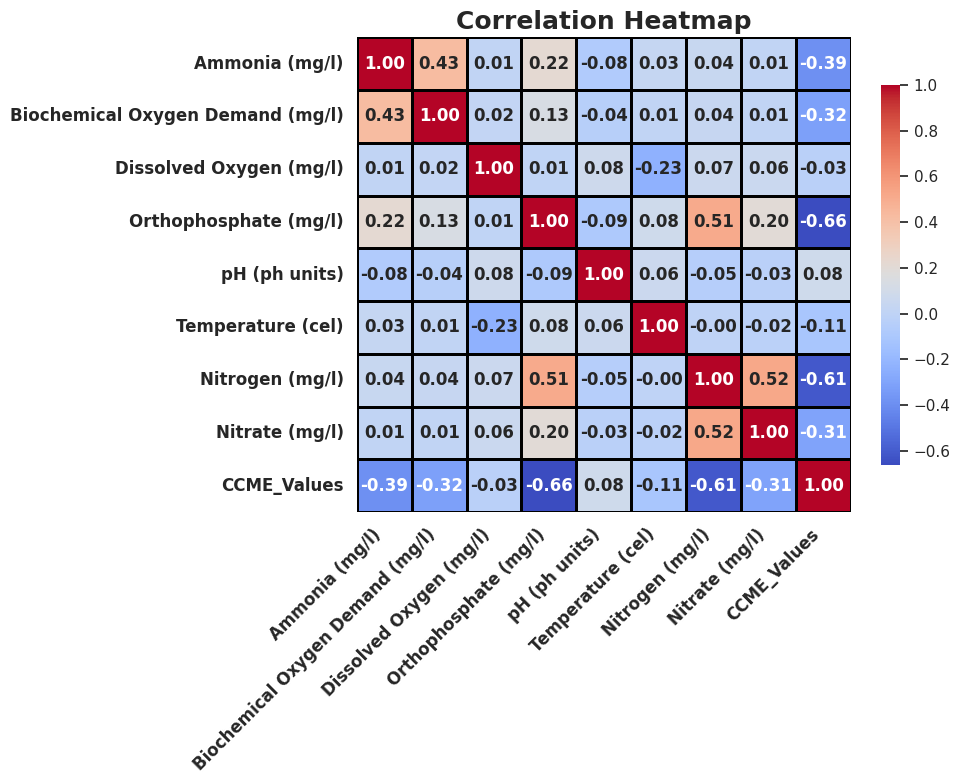

In [8]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [9]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [10]:
 
# --- Merge rare classes ---
df_clean['CCME_WQI'] = df_clean['CCME_WQI'].replace(
    {'Marginal': 'Non-Potable Water', 'Poor': 'Non-Potable Water'}
)

# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])


Columns after encoding: 23


In [11]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class_order = ["Non-Potable Water", "Fair", "Good", "Excellent"]
cat_type    = pd.CategoricalDtype(categories=class_order, ordered=True)

df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")

Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [12]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_WQI"].astype(cat_type).cat.codes.values
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val.columns = X_train.columns
X_test.columns = X_train.columns

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")

Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [13]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.int64)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")

Windowing: 100%|██████████| 9005/9005 [04:50<00:00, 31.01area/s]


Train seq: (440536, 8, 16) | Val: (348027, 8, 16) | Test: (359950, 8, 16)


In [13]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [14]:
# ─────────────────────────────────────────────
# SECTION 6: DataLoaders with WeightedRandomSampler
# ─────────────────────────────────────────────
num_classes = len(class_order)

class_weights_np = compute_class_weight('balanced',
                                        classes=np.unique(y_train_seq),
                                        y=y_train_seq)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

# WeightedRandomSampler 
sample_weights = class_weights_np[y_train_seq]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True
)

X_train_t = torch.FloatTensor(X_train_seq)
y_train_t = torch.LongTensor(y_train_seq)
X_val_t   = torch.FloatTensor(X_val_seq).to(device)
y_val_t   = torch.LongTensor(y_val_seq).to(device)
X_test_t  = torch.FloatTensor(X_test_seq).to(device)
y_test_t  = torch.LongTensor(y_test_seq).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, sampler=sampler)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Class weights:", {class_order[i]: f"{w:.4f}" for i, w in enumerate(class_weights_np)})


Class weights: {'Non-Potable Water': '1.9252', 'Fair': '2.2458', 'Good': '0.6610', 'Excellent': '0.6569'}


In [15]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   Dual-Branch Cross-Attention Transformer
# ─────────────────────────────────────────────

class FeatureEmbedding(nn.Module):
    """Projects each scalar feature to a d_model-dim vector."""
    def __init__(self, num_features, d_model):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(num_features)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, F]
        B, T, F = x.shape
        embedded = []
        for i, emb in enumerate(self.embeddings):
            embedded.append(emb(x[:, :, i:i+1]))   # [B, T, d_model]
        out = torch.stack(embedded, dim=2)           # [B, T, F, d_model]
        return self.norm(out)


class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


In [16]:
# ── Branch 1: Feature Transformer ────────────────────────────────────────
class FeatureTransformer(nn.Module):
    """
    Self-Attention across features at every time step.
    Captures chemical relationships: how Ammonia affects pH, etc.
    Input:  [B, T, F, d_model]
    Output: [B, T, d_model]
    """
    def __init__(self, d_model, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, F, d_model]
        B, T, F, D = x.shape
        x_flat = x.view(B * T, F, D)         # treat time as batch
        out    = self.encoder(x_flat)         # [B*T, F, D]
        out    = out.mean(dim=1)              # pool over features → [B*T, D]
        out    = out.view(B, T, D)            # [B, T, D]
        return self.norm(out)


In [17]:
# ── Branch 2: Temporal Transformer ───────────────────────────────────────
class TemporalTransformer(nn.Module):
    """
    Self-Attention across time steps.
    Captures temporal evolution: gradual quality degradation, seasonal trends.
    Input:  [B, T, input_dim]
    Output: [B, T, d_model]
    """
    def __init__(self, input_dim, d_model, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.proj    = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, input_dim]
        x = self.proj(x)           # [B, T, d_model]
        x = self.pos_enc(x)
        x = self.encoder(x)        # [B, T, d_model]
        return self.norm(x)


In [18]:
# ── Fusion: Cross-Attention ───────────────────────────────────────────────
class CrossAttentionFusion(nn.Module):
    """
    Feature branch  → Query
    Temporal branch → Key, Value
    Attention(Q,K,V) = softmax(QK^T / sqrt(dk)) V
    Learns WHICH feature was MOST INFLUENTIAL at WHICH time step.
    """
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, feat_out, temp_out):
        # feat_out: [B, T, D]  → Query
        # temp_out: [B, T, D]  → Key & Value
        attn_out, attn_weights = self.cross_attn(
            query=feat_out, key=temp_out, value=temp_out
        )
        fused = self.norm(feat_out + self.dropout(attn_out))
        return fused, attn_weights   # attn_weights: [B, T, T]

In [19]:

# ── Full Model ────────────────────────────────────────────────────────────
class DualBranchWQTransformer(nn.Module):
    """
    Dual-Branch Cross-Attention Transformer for Water Quality Classification.

    Architecture:
        Input ──┬── FeatureTransformer  (Q) ──┐
                │                              ├── CrossAttention → Pool → Classify
                └── TemporalTransformer (K,V) ─┘
    """
    def __init__(self, input_dim, d_model=128, n_heads=4,
                 feat_layers=2, temp_layers=2,
                 num_classes=4, dropout=0.15):
        super().__init__()
        self.input_dim = input_dim
        self.d_model   = d_model

        # Branch 1 – Feature Transformer
        self.feat_embed       = FeatureEmbedding(input_dim, d_model)
        self.feat_transformer = FeatureTransformer(d_model, n_heads,
                                                   feat_layers, dropout)

        # Branch 2 – Temporal Transformer
        self.temp_transformer = TemporalTransformer(input_dim, d_model,
                                                    n_heads, temp_layers, dropout)

        # Fusion
        self.cross_attn = CrossAttentionFusion(d_model, n_heads, dropout)

        # Classifier head – deeper for better accuracy
        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(d_model // 2, num_classes)
        )

        # Store attention for XAI
        self.last_attn_weights = None

    def forward(self, x):
        # x: [B, T, F]

        # Branch 1: Feature relationships
        feat_emb = self.feat_embed(x)                  # [B, T, F, D]
        feat_out = self.feat_transformer(feat_emb)     # [B, T, D]

        # Branch 2: Temporal dynamics
        temp_out = self.temp_transformer(x)            # [B, T, D]

        # Cross-Attention Fusion
        fused, attn_w = self.cross_attn(feat_out, temp_out)  # [B, T, D]
        self.last_attn_weights = attn_w.detach()

        # Global pool + classify
        fused   = fused.transpose(1, 2)                # [B, D, T]
        pooled  = self.pool(fused).squeeze(-1)         # [B, D]
        logits  = self.classifier(pooled)
        return logits


input_size  = X_train_seq.shape[2]
num_classes = len(class_order)

model = DualBranchWQTransformer(
    input_dim=input_size,
    d_model=256,       # ↑ زيادة السعة من 128 إلى 256
    n_heads=8,         # ↑ زيادة رؤوس الانتباه
    feat_layers=3,     # ↑ طبقات إضافية
    temp_layers=3,     # ↑ طبقات إضافية
    num_classes=num_classes,
    dropout=0.10       # ↓ تقليل dropout لتحسين التعلم
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel Parameters: {num_params:,}")


 


Model Parameters: 5,116,036


In [20]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Label Smoothing CrossEntropy ─ يقلل الـ Overfitting
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1      # ← Label Smoothing
)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-5)

# OneCycleLR – أفضل scheduler لتحسين الـ Accuracy بسرعة
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    steps_per_epoch=len(train_loader),
    epochs=200,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

NUM_EPOCHS     = 200   # ↑ زيادة عدد الـ epochs
PATIENCE       = 50  # ↑ زيادة الصبر
MIN_DELTA      = 0.001
GRADIENT_CLIP  = 1.0

In [21]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities  ← NEW
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"          # directory for all checkpoints
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                     best_val_bal_acc, path=CHECKPOINT_PATH):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, and best validation score.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path = path + ".tmp"
    checkpoint = {
        "epoch":            epoch,
        "model_state":      model.state_dict(),
        "optimizer_state":  optimizer.state_dict(),
        "scheduler_state":  scheduler.state_dict() if scheduler else None,
        "best_val_bal_acc": best_val_bal_acc,
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state.
    Returns (start_epoch, best_val_bal_acc).
    If checkpoint does not exist → returns (0, 0.0) to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, 0.0

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch      = ckpt["epoch"] + 1   # resume AFTER the saved epoch
    best_val_bal_acc = ckpt["best_val_bal_acc"]

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val Bal.Acc so far: {best_val_bal_acc:.2f}%")
    return start_epoch, best_val_bal_acc


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [22]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop  (checkpointing added)
# ─────────────────────────────────────────────
train_losses, train_accs, train_bal_accs = [], [], []
val_losses,   val_accs,   val_bal_accs   = [], [], []
learning_rates = []

# ── CHANGE: load checkpoint → sets start_epoch & best_val_bal_acc ─────
start_epoch, best_val_bal_acc = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None
# ──────────────────────────────────────────────────────────────────────

print("\n" + "="*120)
print(f"{'Epoch':<8}|{'TrainLoss':<12}|{'TrainAcc':<11}|{'TrainBalAcc':<13}|"
      f"{'ValLoss':<11}|{'ValAcc':<10}|{'ValBalAcc':<12}|{'LR':<10}")
print("-"*120)

# ── CHANGE: start from start_epoch instead of 0 ───────────────────────
for epoch in range(start_epoch, NUM_EPOCHS):
# ──────────────────────────────────────────────────────────────────────
    # ── Train ──────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    tr_preds, tr_targets = [], []

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss    += loss.item() * batch_y.size(0)
        preds       = logits.argmax(1)
        tr_correct += (preds == batch_y).sum().item()
        tr_total   += batch_y.size(0)
        tr_preds.extend(preds.cpu().numpy())
        tr_targets.extend(batch_y.cpu().numpy())
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()  # OneCycleLR: step per batch

    tr_loss    /= tr_total
    tr_acc      = 100 * tr_correct / tr_total
    tr_bal_acc  = 100 * balanced_accuracy_score(tr_targets, tr_preds)
    train_losses.append(tr_loss); train_accs.append(tr_acc); train_bal_accs.append(tr_bal_acc)

    # ── Validate ────────────────────────────────────────────────────
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    v_preds, v_targets = [], []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            logits  = model(batch_x)
            loss    = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            preds   = logits.argmax(1)
            v_correct += (preds == batch_y).sum().item()
            v_total   += batch_y.size(0)
            v_preds.extend(preds.cpu().numpy())
            v_targets.extend(batch_y.cpu().numpy())

    v_loss    /= v_total
    v_acc      = 100 * v_correct / v_total
    v_bal_acc  = 100 * balanced_accuracy_score(v_targets, v_preds)
    val_losses.append(v_loss); val_accs.append(v_acc); val_bal_accs.append(v_bal_acc)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<12.4f}|{tr_acc:<11.2f}|{tr_bal_acc:<13.2f}|"
          f"{v_loss:<11.4f}|{v_acc:<10.2f}|{v_bal_acc:<12.2f}|{current_lr:<10.6f}")

    # ── CHANGE: save checkpoint every epoch (fault-tolerant) ──────────
    save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_bal_acc, path=CHECKPOINT_PATH)
    # ──────────────────────────────────────────────────────────────────

    if v_bal_acc > best_val_bal_acc + MIN_DELTA:
        best_val_bal_acc = v_bal_acc
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        # ── CHANGE: save best model to disk immediately ────────────────
        save_checkpoint(epoch, model, optimizer, scheduler,
                        best_val_bal_acc, path=BEST_MODEL_PATH)
        print(f"   ✔ Best model saved! (Val Bal.Acc: {v_bal_acc:.2f}%)")
        # ────────────────────────────────────────────────────────────────
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*120)
print(f"Best Val Balanced Accuracy: {best_val_bal_acc:.2f}%")
checkpoint = torch.load(BEST_MODEL_PATH)
model.load_state_dict(checkpoint["model_state"])

[Checkpoint] Resuming from: ./checkpoints/checkpoint_latest.pth
[Checkpoint] Scheduler state restored.
[Checkpoint] Resumed at epoch 200 | Best Val Bal.Acc so far: 99.16%

Epoch   |TrainLoss   |TrainAcc   |TrainBalAcc  |ValLoss    |ValAcc    |ValBalAcc   |LR        
------------------------------------------------------------------------------------------------------------------------
Best Val Balanced Accuracy: 99.16%


<All keys matched successfully>

In [23]:
# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_correct, t_total = 0.0, 0, 0
t_preds, t_targets, t_probs = [], [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item()
        preds   = out.argmax(1)
        t_correct += (preds == batch_y).sum().item()
        t_total   += batch_y.size(0)
        t_preds.extend(preds.cpu().numpy())
        t_targets.extend(batch_y.cpu().numpy())
        t_probs.extend(torch.softmax(out, 1).cpu().numpy())

t_probs    = np.array(t_probs)
t_targets  = np.array(t_targets)
t_preds    = np.array(t_preds)
test_acc   = 100 * t_correct / t_total
test_bal   = 100 * balanced_accuracy_score(t_targets, t_preds)
test_loss  = t_loss / len(test_loader)

print(f"\nTest Acc: {test_acc:.2f}% | Bal.Acc: {test_bal:.2f}% | Loss: {test_loss:.4f}")
print(classification_report(t_targets, t_preds, target_names=class_order, digits=4))



Test Acc: 99.37% | Bal.Acc: 99.21% | Loss: 0.5197
                   precision    recall  f1-score   support

Non-Potable Water     0.9913    0.9916    0.9915     48563
             Fair     0.9703    0.9869    0.9785     42196
             Good     0.9980    0.9910    0.9945    131549
        Excellent     0.9977    0.9990    0.9984    137642

         accuracy                         0.9937    359950
        macro avg     0.9893    0.9921    0.9907    359950
     weighted avg     0.9937    0.9937    0.9937    359950



In [24]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
def plot_curve(train_vals, val_vals, ylabel, title, best_val):
    fig, ax = plt.subplots(figsize=(14, 8))
    ep = np.arange(1, len(train_vals) + 1)
    ax.plot(ep, train_vals, marker='o', linewidth=3, markersize=8,
            label=f'Training {ylabel}', color='#FF6B6B', alpha=0.85)
    ax.plot(ep, val_vals,   marker='s', linewidth=3, markersize=8,
            label=f'Validation {ylabel}', color='#4ECDC4', alpha=0.85)
    ax.fill_between(ep, train_vals, val_vals, alpha=0.15, color='gray')
    ax.axhline(y=best_val, color='#4ECDC4', linestyle='--', linewidth=2,
               alpha=0.7, label=f'Best Val: {best_val:.2f}')
    ax.set_xlabel('Epoch', fontsize=18, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=18, fontweight='bold')
    ax.set_title(title, fontsize=20, fontweight='bold', pad=20)
    ax.legend(fontsize=14); ax.grid(True, alpha=0.4)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
    plt.tight_layout(); plt.show()

plot_curve(train_bal_accs, val_bal_accs, 'Balanced Accuracy (%)',
           'Model Balanced Accuracy Over Epochs', np.max(val_bal_accs))
plot_curve(train_accs, val_accs, 'Accuracy (%)',
           'Model Accuracy Over Epochs', np.max(val_accs))
plot_curve(train_losses, val_losses, 'Loss',
           'Model Loss Over Epochs', np.min(val_losses))


ValueError: zero-size array to reduction operation maximum which has no identity

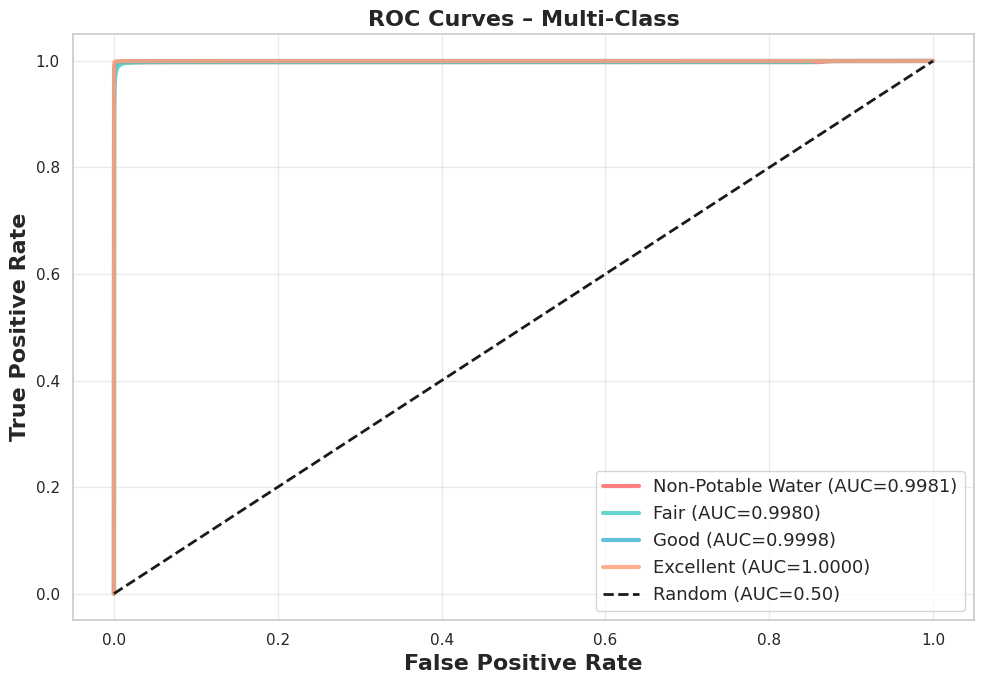

In [25]:
# ─────────────────────────────────────────────
# SECTION 12: ROC Curves
# ─────────────────────────────────────────────
y_test_bin   = label_binarize(t_targets, classes=[0, 1, 2, 3])
colors_roc   = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
roc_auc_list = []

fig, ax = plt.subplots(figsize=(10, 7))
for i, cls in enumerate(class_order):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], t_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    roc_auc_list.append(roc_auc)
    ax.plot(fpr, tpr, linewidth=3, label=f'{cls} (AUC={roc_auc:.4f})',
            color=colors_roc[i], alpha=0.85)
ax.plot([0,1],[0,1],'k--', linewidth=2, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=16, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=16, fontweight='bold')
ax.set_title('ROC Curves – Multi-Class', fontsize=16, fontweight='bold')
ax.legend(fontsize=13); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


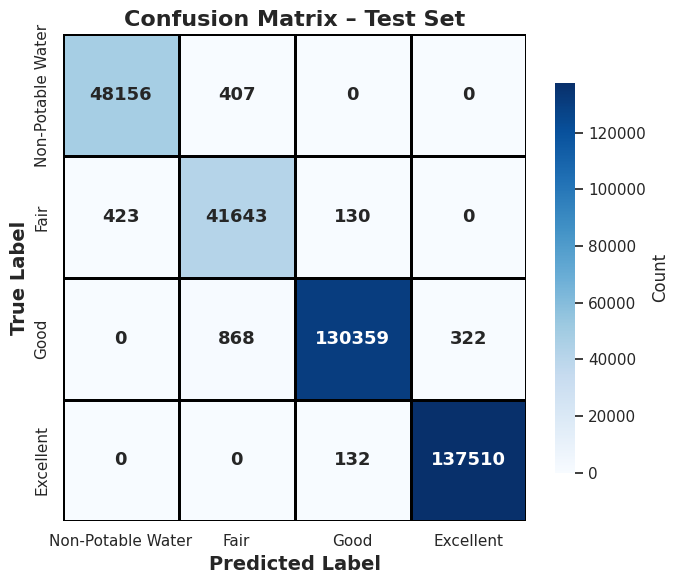

In [26]:

# ─────────────────────────────────────────────
# SECTION 13: Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(t_targets, t_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order,
            cbar_kws={'label': 'Count', 'shrink': 0.8}, ax=ax,
            annot_kws={'fontsize': 13, 'weight': 'bold'},
            linewidths=2, linecolor='black')
ax.set_title('Confusion Matrix – Test Set', fontsize=16, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

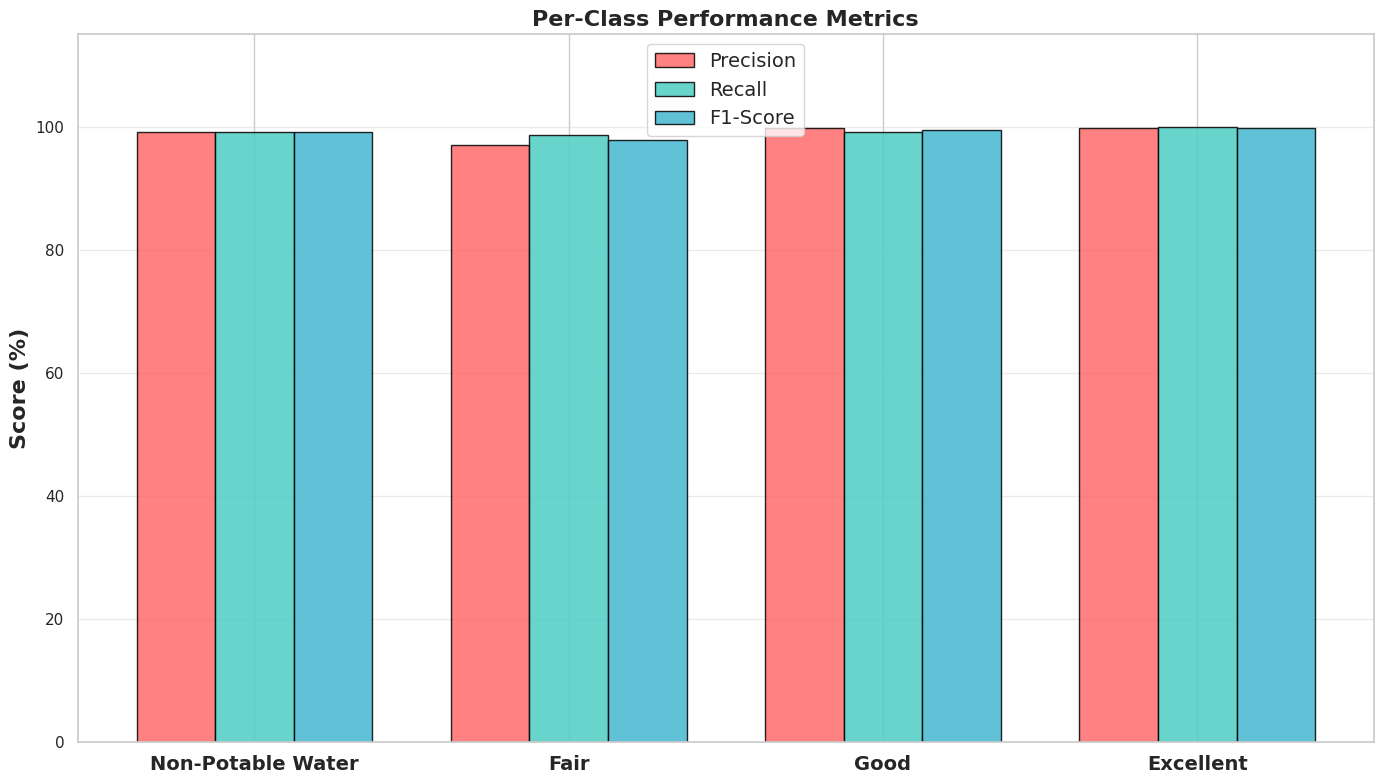

In [27]:
# ─────────────────────────────────────────────
# SECTION 14: Per-Class Metrics Bar Chart
# ─────────────────────────────────────────────
prec = precision_score(t_targets, t_preds, average=None, zero_division=0)
rec  = recall_score(t_targets, t_preds, average=None, zero_division=0)
f1c  = f1_score(t_targets, t_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(class_order)); w = 0.25
ax.bar(x - w, prec * 100, w, label='Precision', color='#FF6B6B', edgecolor='black', alpha=0.85)
ax.bar(x,     rec  * 100, w, label='Recall',    color='#4ECDC4', edgecolor='black', alpha=0.85)
ax.bar(x + w, f1c  * 100, w, label='F1-Score',  color='#45B7D1', edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(class_order, fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=16, fontweight='bold')
ax.legend(fontsize=14); ax.set_ylim([0, 115]); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] Extracting Attention Rollout Heatmaps...
['Ammonia_mg_l', 'Biochemical_Oxygen_Demand_mg_l', 'Dissolved_Oxygen_mg_l', 'Orthophosphate_mg_l', 'pH_ph_units', 'Temperature_cel', 'Nitrogen_mg_l', 'Nitrate_mg_l', 'Month_sin', 'Month_cos', 'Waterbody_Type_Artificial', 'Waterbody_Type_Coastal_Marine', 'Waterbody_Type_Lake', 'Waterbody_Type_Minor_Waterbodies', 'Waterbody_Type_River', 'Waterbody_Type_Wastewater']


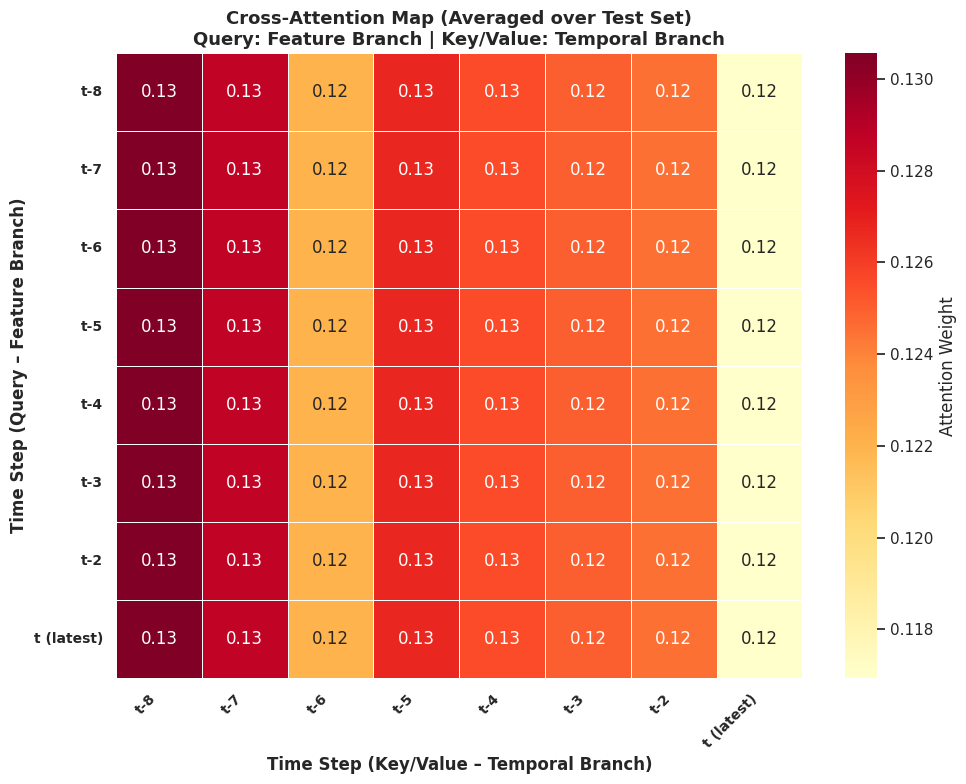

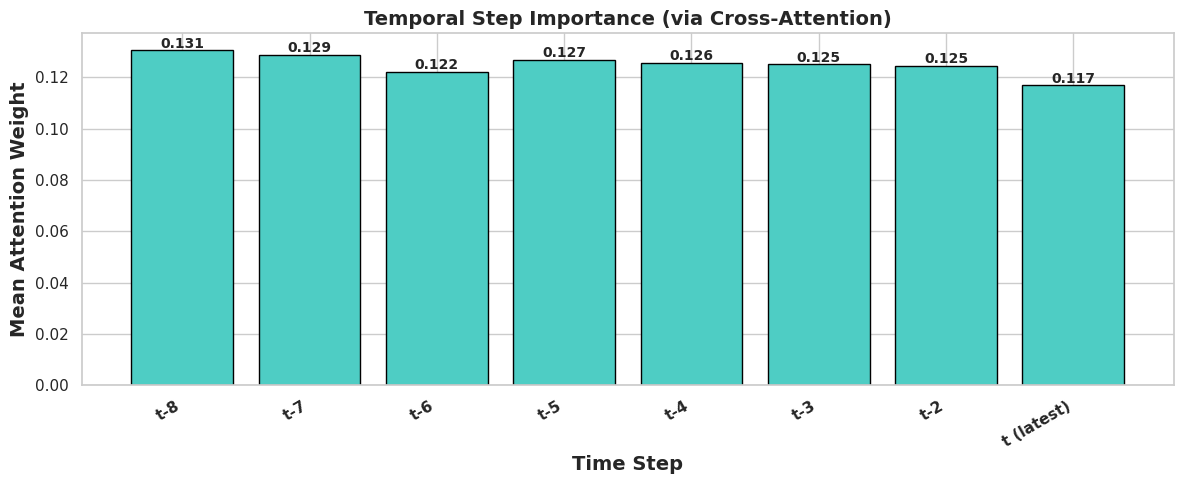

In [28]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – Attention Rollout Heatmap
# ─────────────────────────────────────────────
print("\n[XAI] Extracting Attention Rollout Heatmaps...")
SEQ_LEN = 8
feature_names = X_train.columns.tolist()
print(feature_names)
model.eval()

attn_maps_all = []   # collect over test batches
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)
        attn_maps_all.append(model.last_attn_weights.cpu().numpy())  # [B, T, T]

attn_maps_all = np.concatenate(attn_maps_all, axis=0)   # [N, T, T]

# Global: mean cross-attention over test set
mean_attn = attn_maps_all.mean(axis=0)    # [T, T]

# ── أسماء خطوات الزمن بدل الأرقام ──
time_step_labels = [f"t-{SEQ_LEN - i}" if i < SEQ_LEN - 1 else "t (latest)"
                    for i in range(SEQ_LEN)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mean_attn, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attention Weight'},
            xticklabels=time_step_labels,   # ← أسماء محور X
            yticklabels=time_step_labels)   # ← أسماء محور Y
ax.set_title('Cross-Attention Map (Averaged over Test Set)\n'
             'Query: Feature Branch | Key/Value: Temporal Branch',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step (Key/Value – Temporal Branch)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time Step (Query – Feature Branch)',       fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,   fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-time-step importance vector – بأسماء الخطوات
time_importance = mean_attn.mean(axis=0)   # [T]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(time_step_labels, time_importance, color='#4ECDC4', edgecolor='black')
for bar, val in zip(bars, time_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Attention Weight', fontsize=14, fontweight='bold')
ax.set_title('Temporal Step Importance (via Cross-Attention)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(time_step_labels, rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()



[XAI] SHAP Gradient Explainer...


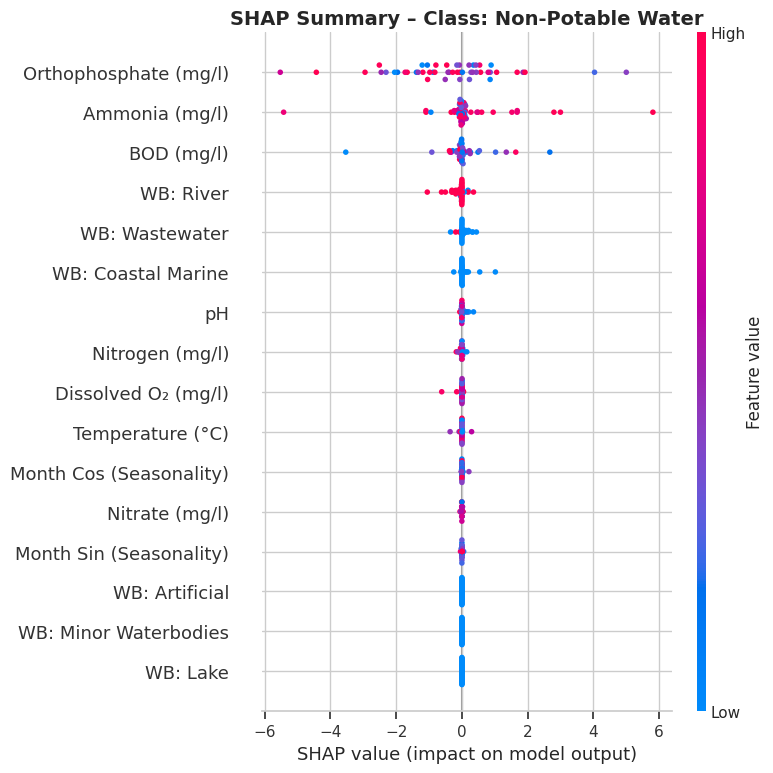

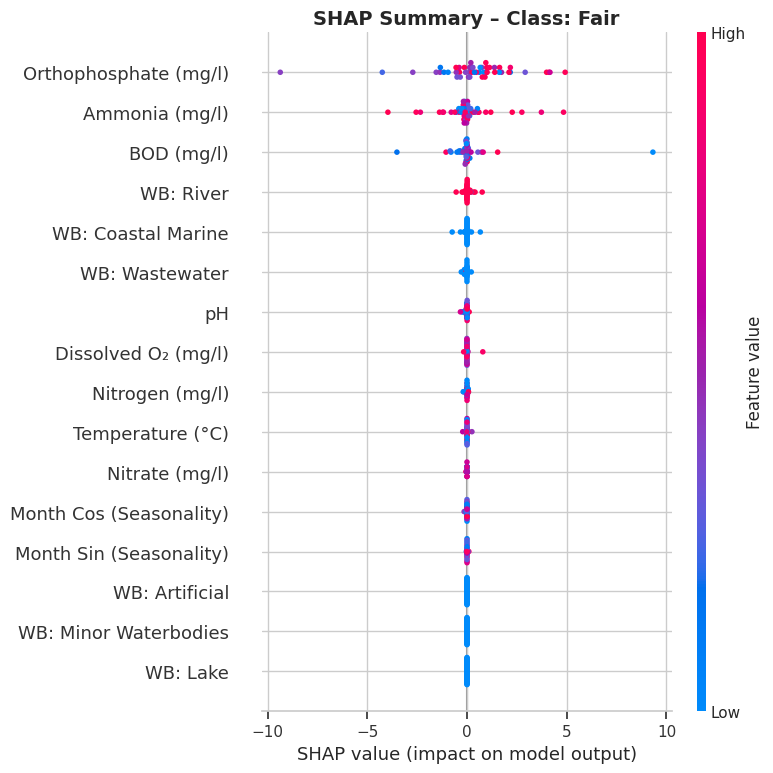

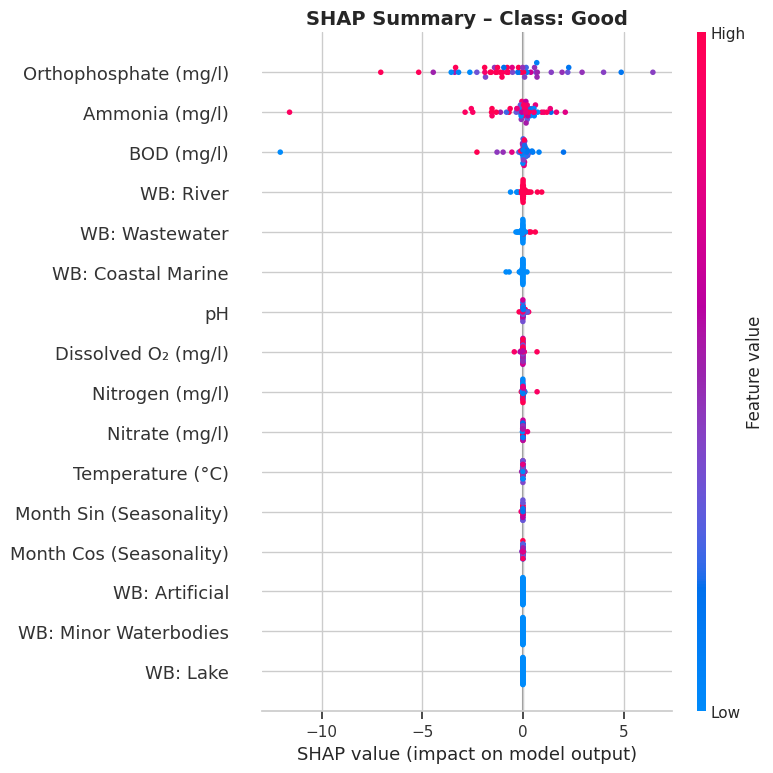

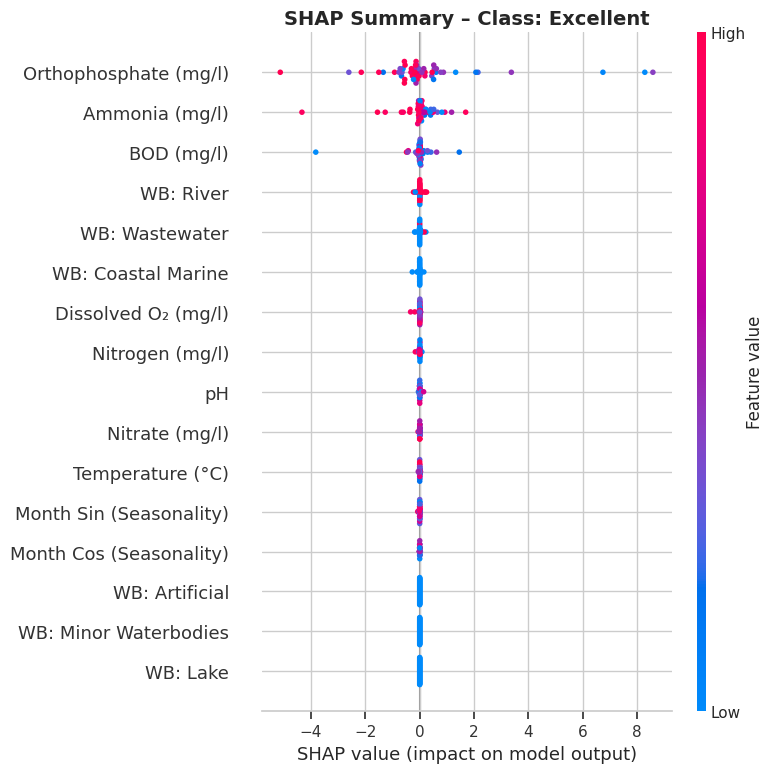

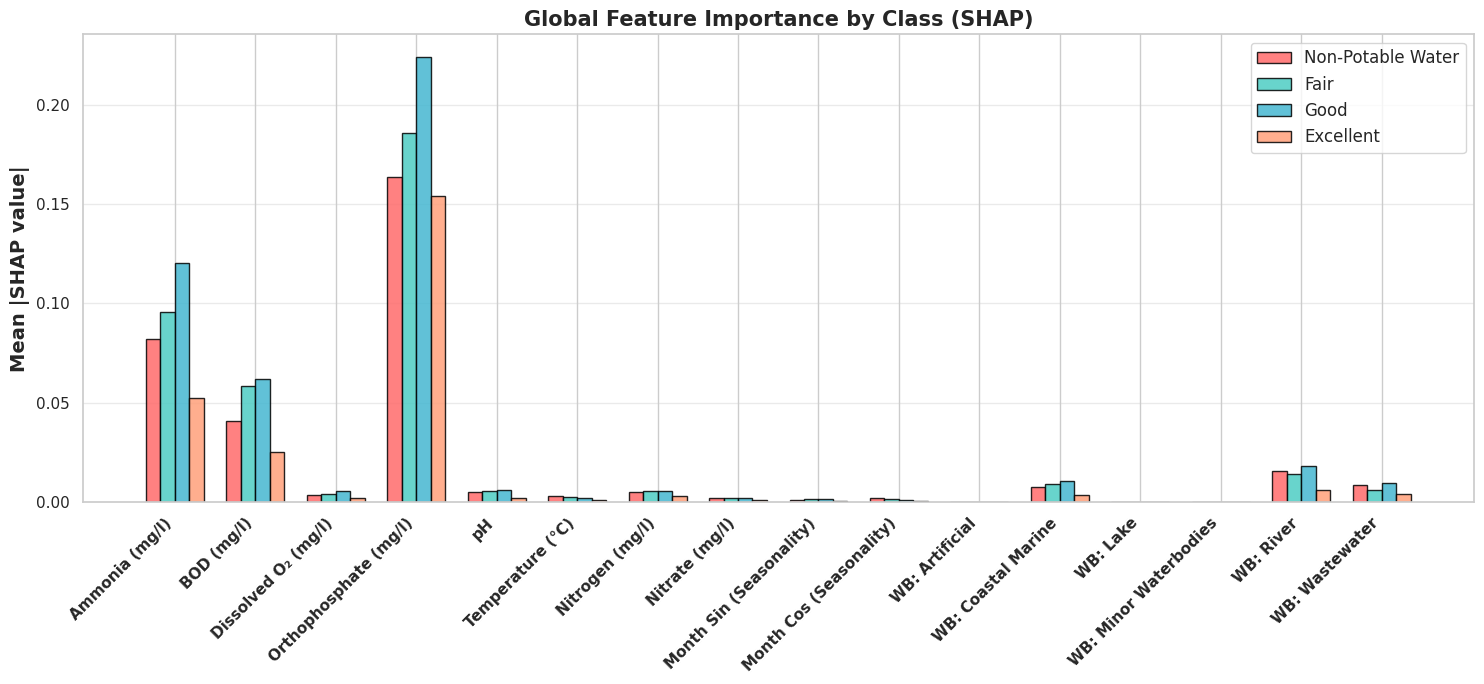

In [29]:
# ─────────────────────────────────────────────
# SECTION 16: XAI – SHAP GradientExplainer
# ─────────────────────────────────────────────
import shap

print("\n[XAI] SHAP Gradient Explainer...")
background  = X_train_t[:100].to(device)
explainer   = shap.GradientExplainer(model, background)
test_sample = X_test_t[:50].to(device)

shap_raw = explainer.shap_values(test_sample)

# ── Handle both shap API versions ──────────────────────────────────────
# Old API: list of arrays [num_classes × (50, T, F)]
# New API: single array (50, T, F, num_classes)
if isinstance(shap_raw, list):
    shap_values = shap_raw                          # list[4] each [50, T, F]
else:
    shap_values = [shap_raw[..., i]
                   for i in range(shap_raw.shape[-1])]  # split last dim

# ── أسماء المتغيرات بصورة مقروءة بدل الأسماء المشفرة ──
raw_feature_names = X_train.columns.tolist()
feature_name_map = {
    'Ammonia_mg_l':                    'Ammonia (mg/l)',
    'Biochemical_Oxygen_Demand_mg_l':  'BOD (mg/l)',
    'Dissolved_Oxygen_mg_l':           'Dissolved O₂ (mg/l)',
    'Orthophosphate_mg_l':             'Orthophosphate (mg/l)',
    'pH_ph_units':                     'pH',
    'Temperature_cel':                 'Temperature (°C)',
    'Nitrogen_mg_l':                   'Nitrogen (mg/l)',
    'Nitrate_mg_l':                    'Nitrate (mg/l)',
    'Month_sin':                       'Month Sin (Seasonality)',
    'Month_cos':                       'Month Cos (Seasonality)',
}
feature_names_display = [feature_name_map.get(c, c.replace('_', ' ').replace('Waterbody Type ', 'WB: '))
                         for c in raw_feature_names]

# ── Collapse temporal dimension for plotting ────────────────────────────
# sv per class: [50, T, F] → sum over T → [50, F]
# input:        [50, T, F] → mean over T → [50, F]
test_np   = test_sample.cpu().numpy()           # [50, T, F]
input_2d  = test_np.mean(axis=1)                # [50, F]  ← mean over time

# --- Summary plot for each class – with readable names ---
for cls_idx, cls_name in enumerate(class_order):
    sv_3d = shap_values[cls_idx]                # [50, T, F]
    sv_2d = sv_3d.sum(axis=1)                   # [50, F]  ← sum over time

    # Sanity check – shapes must match
    assert sv_2d.shape == input_2d.shape, (
        f"Shape mismatch: sv_2d={sv_2d.shape}, input_2d={input_2d.shape}"
    )

    plt.figure(figsize=(11, 7))
    shap.summary_plot(sv_2d, input_2d,
                      feature_names=feature_names_display,
                      show=False)
    plt.title(f"SHAP Summary – Class: {cls_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_summary_{cls_name.replace(" ", "_")}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

# --- Global feature importance bar – with readable names ---
shap_means = [np.abs(sv).mean(axis=(0, 1)) for sv in shap_values]   # list[4] of [F]

fig, ax = plt.subplots(figsize=(15, 7))
x   = np.arange(len(feature_names_display))
w   = 0.18
off = (np.arange(num_classes) - (num_classes - 1) / 2) * w
colors_shap = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, cls in enumerate(class_order):
    ax.bar(x + off[i], shap_means[i], w, label=cls,
           color=colors_shap[i], edgecolor='black', alpha=0.85)

ax.set_ylabel('Mean |SHAP value|', fontsize=14, fontweight='bold')
ax.set_title('Global Feature Importance by Class (SHAP)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, rotation=45, ha='right',
                   fontsize=11, fontweight='bold')
ax.legend(fontsize=12); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('global_feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()


In [30]:
# ─────────────────────────────────────────────
# SECTION 17: XAI – Local Explanation Report
# ─────────────────────────────────────────────
print("\n[XAI] Local Explanations (5 test samples):")
print("="*80)

for sample_idx in range(5):
    true_cls = class_order[t_targets[sample_idx]]
    pred_cls = class_order[t_preds[sample_idx]]

    # Feature importance: SHAP values for predicted class, summed across time
    sv = shap_values[t_preds[sample_idx]][sample_idx]   # [T, F]
    sv_sum = sv.sum(axis=0)                              # [F]
    top_k  = np.argsort(np.abs(sv_sum))[::-1][:3]       # top-3 features

    top_feats = [(feature_names_display[i], sv_sum[i]) for i in top_k]
    feat_str  = ", ".join([f"{n}({'↑' if v > 0 else '↓'}{abs(v):.3f})"
                           for n, v in top_feats])

    print(f"Sample {sample_idx+1}: True={true_cls} | Pred={pred_cls}")
    print(f"   → Key drivers: {feat_str}")
    print()




[XAI] Local Explanations (5 test samples):
Sample 1: True=Good | Pred=Good
   → Key drivers: Orthophosphate (mg/l)(↑2.277), BOD (mg/l)(↑0.488), Ammonia (mg/l)(↑0.121)

Sample 2: True=Good | Pred=Good
   → Key drivers: Orthophosphate (mg/l)(↑4.884), Ammonia (mg/l)(↑0.555), BOD (mg/l)(↑0.121)

Sample 3: True=Fair | Pred=Fair
   → Key drivers: Orthophosphate (mg/l)(↓4.247), BOD (mg/l)(↓3.514), Ammonia (mg/l)(↓2.337)

Sample 4: True=Fair | Pred=Fair
   → Key drivers: Ammonia (mg/l)(↑3.729), Orthophosphate (mg/l)(↑2.917), Nitrogen (mg/l)(↓0.064)

Sample 5: True=Fair | Pred=Fair
   → Key drivers: Orthophosphate (mg/l)(↓9.362), WB: Wastewater(↓0.176), WB: River(↑0.154)



In [31]:
# ─────────────────────────────────────────────
# SECTION 18: DiCE – Counterfactual Explanations
# ─────────────────────────────────────────────
try:
    import dice_ml
    from dice_ml import Dice
    print("\n[DiCE] Counterfactual Explanations...")

    from sklearn.base import BaseEstimator, ClassifierMixin

    class TorchModelWrapper(BaseEstimator, ClassifierMixin):
        def __init__(self, model, device, preprocessor, feature_names, seq_len=8):
            self.model         = model
            self.device        = device
            self.preprocessor  = preprocessor
            self.feature_names = feature_names
            self.seq_len       = seq_len

        def predict(self, X):
            return self.predict_proba(X).argmax(axis=1)

        def predict_proba(self, X):
            if isinstance(X, pd.DataFrame):
                X = X.values
            X_proc = self.preprocessor.transform(
                pd.DataFrame(X, columns=self.feature_names)
            ).astype(np.float32)
            X_seq = np.stack([X_proc] * self.seq_len, axis=1)
            X_t   = torch.FloatTensor(X_seq).to(self.device)
            self.model.eval()
            with torch.no_grad():
                logits = self.model(X_t)
                probs  = torch.softmax(logits, dim=1).cpu().numpy()
            return probs

    wrapped_model = TorchModelWrapper(model, device, preprocessor,
                                      X_train.columns.tolist(), seq_len=SEQ_LEN)

    # Build DiCE data object
    dice_data_df = X_train.copy()
    dice_data_df['CCME_WQI'] = pd.Categorical(
        pd.Series(y_train).map({i: c for i, c in enumerate(class_order)}),
        categories=class_order
    ).codes

    # Immutable features
    immutable = ['Temperature_cel', 'Month_sin', 'Month_cos'] + \
                [c for c in X_train.columns if c.startswith('Waterbody')]

    all_features = X_train.columns.tolist()

    d = dice_ml.Data(
        dataframe=pd.concat([dice_data_df,
                             pd.Series(y_train, name='CCME_WQI')], axis=1),
        continuous_features=all_features,
        outcome_name='CCME_WQI'
    )

    m   = dice_ml.Model(model=wrapped_model, backend='sklearn')
    exp = Dice(d, m, method='random')

    # ✅ class_order = ['Poor'=0, 'Marginal'=1, 'Good'=2, 'Excellent'=3]
    # نبحث عن samples الـ Poor (index=0) من الـ predicted classes
    poor_idx = np.where(t_preds == 0)[0]   # ← Poor من الـ predictions

    print(f"[DiCE] Found {len(poor_idx)} Poor samples in test set")

    if len(poor_idx) > 0:
        sample_cf = X_test.iloc[poor_idx[0]:poor_idx[0]+1]

        # ✅ desired_class = 2 = 'Good'
        cf_result = exp.generate_counterfactuals(
            sample_cf, total_CFs=3,
            desired_class=2,   # Good
            features_to_vary=[c for c in X_train.columns if c not in immutable]
        )
        print("\n[DiCE] Counterfactuals for Poor Water → Good:")
        cf_result.visualize_as_dataframe(show_only_changes=True)
    else:
        print("[DiCE] No Poor samples found in test set.")

except ImportError:
    print("\n[DiCE] Install via: pip install dice-ml")
    print("       Skipping counterfactual section.")


[DiCE] Counterfactual Explanations...
[DiCE] Found 48579 Poor samples in test set


100%|██████████| 1/1 [00:09<00:00,  9.45s/it]


[DiCE] Counterfactuals for Poor Water → Good:
Query instance (original outcome : 2)


,Ammonia_mg_l,Biochemical_Oxygen_Demand_mg_l,Dissolved_Oxygen_mg_l,Orthophosphate_mg_l,pH_ph_units,Temperature_cel,Nitrogen_mg_l,Nitrate_mg_l,Month_sin,Month_cos,Waterbody_Type_Artificial,Waterbody_Type_Coastal_Marine,Waterbody_Type_Lake,Waterbody_Type_Minor_Waterbodies,Waterbody_Type_River,Waterbody_Type_Wastewater,CCME_WQI
0,0.098,2.9,10.2,0.144,7.32,11.46,5.0,4.5,-1.0,-1.836970e-16,0,0,0,0,1,0,2



Diverse Counterfactual set (new outcome: 2)


,Ammonia_mg_l,Biochemical_Oxygen_Demand_mg_l,Dissolved_Oxygen_mg_l,Orthophosphate_mg_l,pH_ph_units,Temperature_cel,Nitrogen_mg_l,Nitrate_mg_l,Month_sin,Month_cos,Waterbody_Type_Artificial,Waterbody_Type_Coastal_Marine,Waterbody_Type_Lake,Waterbody_Type_Minor_Waterbodies,Waterbody_Type_River,Waterbody_Type_Wastewater,CCME_WQI
0,-,-,-,-,-,-,42.9,-,-,-1.8369701987210297e-16,-,-,-,-,-,-,-
1,-,-,-,-,-,-,26.1,64.0,-,-1.8369701987210297e-16,-,-,-,-,-,-,-
2,-,-,-,-,-,-,39.0,15.9,-,-1.8369701987210297e-16,-,-,-,-,-,-,-



ABLATION STUDY
  [Feature Branch Only]  Bal.Acc=74.65%  Macro-F1=68.16%
  [Temporal Branch Only]  Bal.Acc=94.18%  Macro-F1=92.61%
  [Full Dual-Branch]  Bal.Acc=94.73%  Macro-F1=93.47%


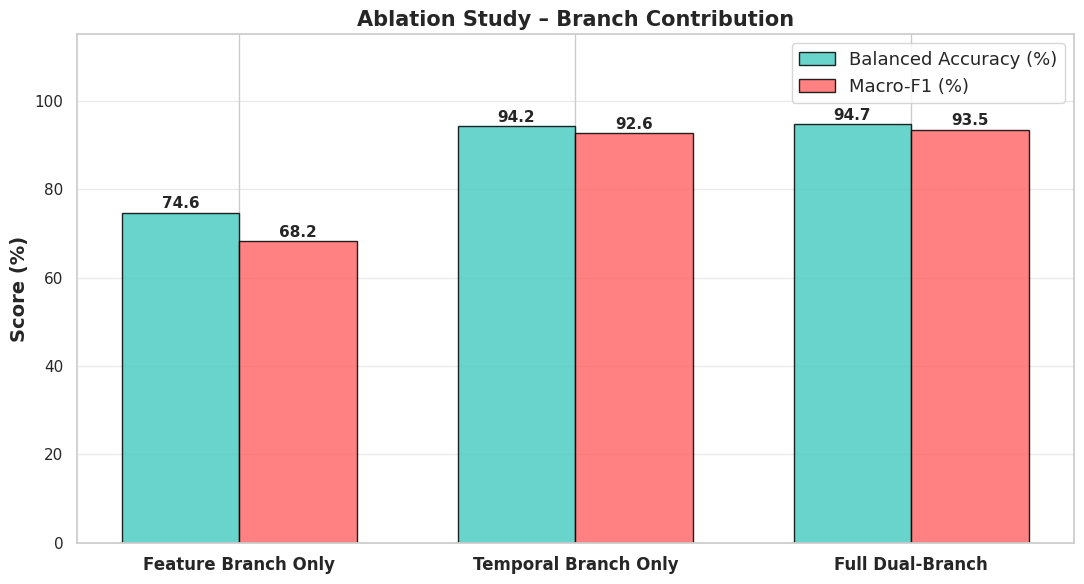

In [34]:
 
# ─────────────────────────────────────────────
# SECTION 19: Ablation Study
# ─────────────────────────────────────────────
print("\n" + "="*80)
print("ABLATION STUDY")
print("="*80)

class AblationModel(nn.Module):
    """Configurable ablation variant."""
    def __init__(self, input_dim, d_model=128, n_heads=4,
                 feat_layers=2, temp_layers=2,
                 num_classes=4, dropout=0.15,
                 use_feature_branch=True,
                 use_temporal_branch=True):
        super().__init__()
        self.use_feat = use_feature_branch
        self.use_temp = use_temporal_branch
        self.d_model  = d_model

        if use_feature_branch:
            self.feat_embed       = FeatureEmbedding(input_dim, d_model)
            self.feat_transformer = FeatureTransformer(d_model, n_heads, feat_layers, dropout)

        if use_temporal_branch:
            self.temp_transformer = TemporalTransformer(input_dim, d_model, n_heads, temp_layers, dropout)

        if use_feature_branch and use_temporal_branch:
            self.cross_attn = CrossAttentionFusion(d_model, n_heads, dropout)

        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        if self.use_feat and self.use_temp:
            feat_emb = self.feat_embed(x)
            feat_out = self.feat_transformer(feat_emb)
            temp_out = self.temp_transformer(x)
            fused, _ = self.cross_attn(feat_out, temp_out)
        elif self.use_feat:
            feat_emb = self.feat_embed(x)
            fused    = self.feat_transformer(feat_emb)
        else:  # temporal only
            fused = self.temp_transformer(x)

        fused  = fused.transpose(1, 2)
        pooled = self.pool(fused).squeeze(-1)
        return self.classifier(pooled)


def quick_train_eval(model_v, name, epochs=30):
    """Short training run for ablation comparison."""
    opt = optim.AdamW(model_v.parameters(), lr=5e-4, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    best_bal = 0.0
    for ep in range(epochs):
        model_v.train()
        for bx, by in train_loader:
            bx = bx.to(device); by = by.to(device)
            loss = crit(model_v(bx), by)
            opt.zero_grad(); loss.backward(); opt.step()

    model_v.eval()
    preds_all, targs_all = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            preds_all.extend(model_v(bx).argmax(1).cpu().numpy())
            targs_all.extend(by.cpu().numpy())

    bal = 100 * balanced_accuracy_score(targs_all, preds_all)
    f1m = 100 * f1_score(targs_all, preds_all, average='macro', zero_division=0)
    print(f"  [{name}]  Bal.Acc={bal:.2f}%  Macro-F1={f1m:.2f}%")
    return bal, f1m


configs = [
    ("Feature Branch Only",   True,  False),
    ("Temporal Branch Only",  False, True),
    ("Full Dual-Branch",      True,  True),
]

ablation_results = {}
for name, uf, ut in configs:
    m_abl = AblationModel(input_size, d_model=128, n_heads=4,
                          feat_layers=2, temp_layers=2,
                          num_classes=num_classes,
                          use_feature_branch=uf,
                          use_temporal_branch=ut).to(device)
    bal, f1m = quick_train_eval(m_abl, name, epochs=4)
    ablation_results[name] = {'Bal.Acc': bal, 'Macro-F1': f1m}

# Ablation bar chart
labels = list(ablation_results.keys())
bal_vals = [ablation_results[k]['Bal.Acc'] for k in labels]
f1_vals  = [ablation_results[k]['Macro-F1'] for k in labels]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w/2, bal_vals, w, label='Balanced Accuracy (%)',
       color='#4ECDC4', edgecolor='black', alpha=0.85)
ax.bar(x + w/2, f1_vals,  w, label='Macro-F1 (%)',
       color='#FF6B6B', edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study – Branch Contribution', fontsize=15, fontweight='bold')
ax.legend(fontsize=13); ax.set_ylim([0, 115]); ax.grid(axis='y', alpha=0.4)
for i, (b, f) in enumerate(zip(bal_vals, f1_vals)):
    ax.text(i - w/2, b + 1, f'{b:.1f}', ha='center', fontsize=11, fontweight='bold')
    ax.text(i + w/2, f + 1, f'{f:.1f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()


In [35]:
# ─────────────────────────────────────────────
# SECTION 20: Final Summary
# ─────────────────────────────────────────────
prec_w = precision_score(t_targets, t_preds, average='weighted', zero_division=0)
rec_w  = recall_score(t_targets,   t_preds, average='weighted', zero_division=0)
f1_w   = f1_score(t_targets,       t_preds, average='weighted', zero_division=0)
f1_mac = f1_score(t_targets,       t_preds, average='macro',    zero_division=0)

print("\n" + "="*100)
print(" FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Cross-Attention Transformer")
print("="*100)
print(f"\n  Test Accuracy:           {test_acc:>8.2f}%")
print(f"  Test Balanced Accuracy:  {test_bal:>8.2f}%")
print(f"  Macro-F1 Score:          {f1_mac*100:>8.2f}%")
print(f"  Weighted F1-Score:       {f1_w*100:>8.2f}%")
print(f"  Weighted Precision:      {prec_w*100:>8.2f}%")
print(f"  Weighted Recall:         {rec_w*100:>8.2f}%")
print(f"  Test Loss:               {test_loss:>8.4f}")

print(f"\n  ROC-AUC Per Class:")
for i, cls in enumerate(class_order):
    print(f"    {cls:<25}: {roc_auc_list[i]:.4f}")

print("\n" + "="*100)
print(classification_report(t_targets, t_preds, target_names=class_order, digits=4))
print("="*100)



 FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Cross-Attention Transformer

  Test Accuracy:              99.37%
  Test Balanced Accuracy:     99.21%
  Macro-F1 Score:             99.07%
  Weighted F1-Score:          99.37%
  Weighted Precision:         99.37%
  Weighted Recall:            99.37%
  Test Loss:                 0.5197

  ROC-AUC Per Class:
    Non-Potable Water        : 0.9981
    Fair                     : 0.9980
    Good                     : 0.9998
    Excellent                : 1.0000

                   precision    recall  f1-score   support

Non-Potable Water     0.9913    0.9916    0.9915     48563
             Fair     0.9703    0.9869    0.9785     42196
             Good     0.9980    0.9910    0.9945    131549
        Excellent     0.9977    0.9990    0.9984    137642

         accuracy                         0.9937    359950
        macro avg     0.9893    0.9921    0.9907    359950
     weighted avg     0.9937    0.9937    0.9937    359950

